In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Total messages processed: 6860
Total messages dropped: 0
      index  Sending_Timestamp  Receiving_Timestamp  twin_id  message_id  \
0         0      1780989815800        1780989815801        1         0.0   
1         1      1780989815900        1780989815900        1         1.0   
2         2      1780989816000        1780989816000        1         2.0   
3         3      1780989816100        1780989816100        1         3.0   
4         4      1780989816200        1780989816200        1         4.0   
...     ...                ...                  ...      ...         ...   
6855   6855      1780990681422        1780990681423        1      6855.0   
6856   6856      1780990681522        1780990681523        1      6856.0   
6857   6857      1780990681622        1780990681623        1      6857.0   
6858   6858      1780990681722        1780990681723        1      6858.0   
6859   6859      1780990681822        1780990681823        1      6859.0   

      latency  grupo  arrived_

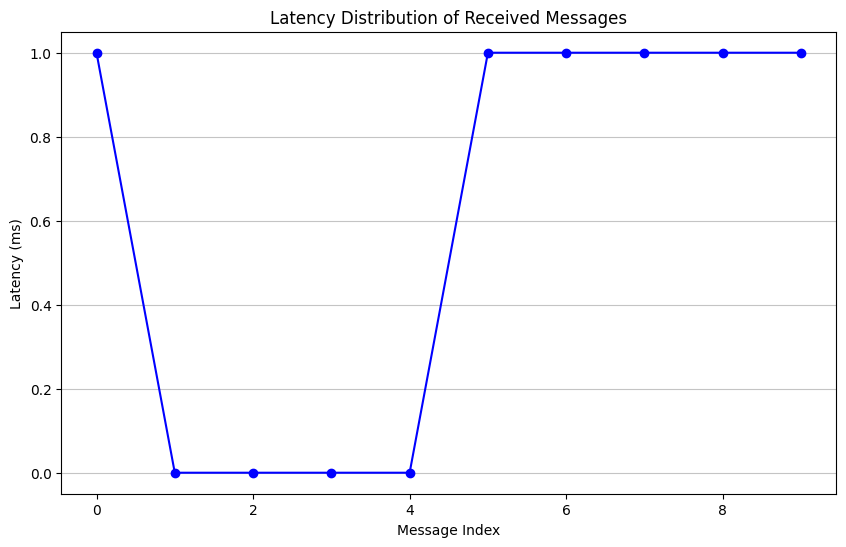

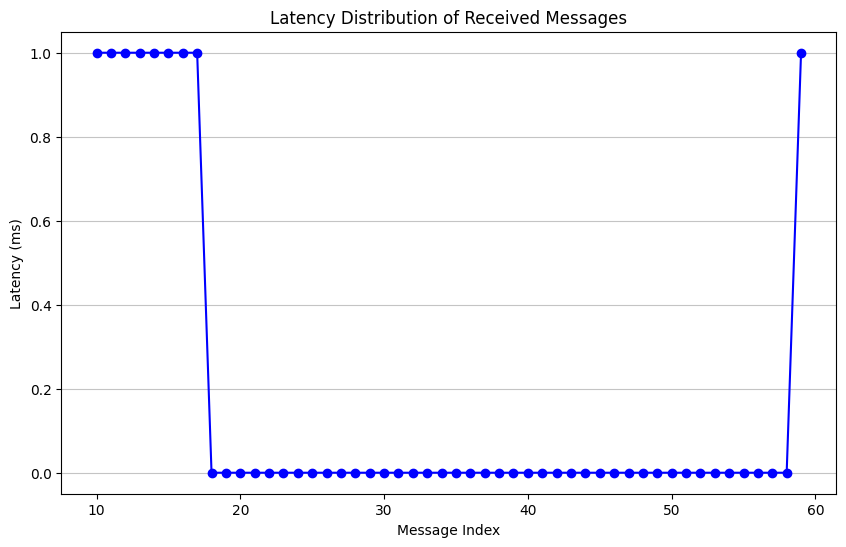

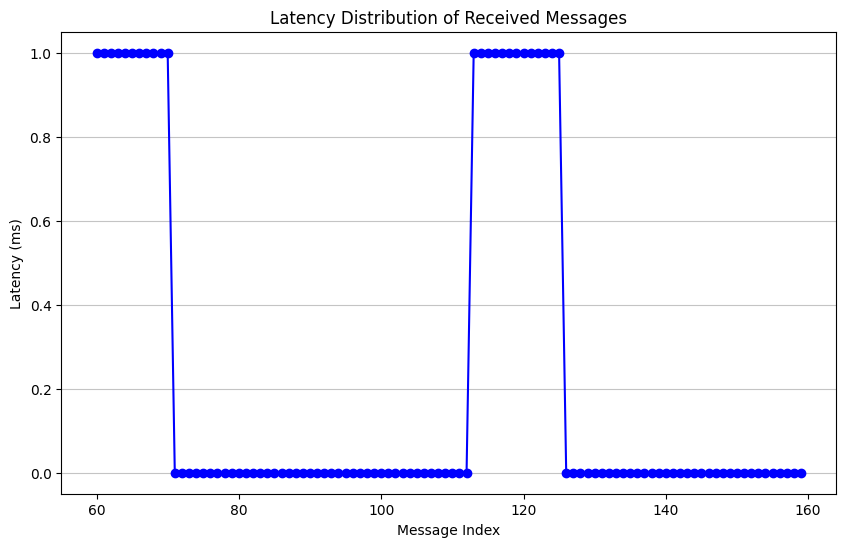

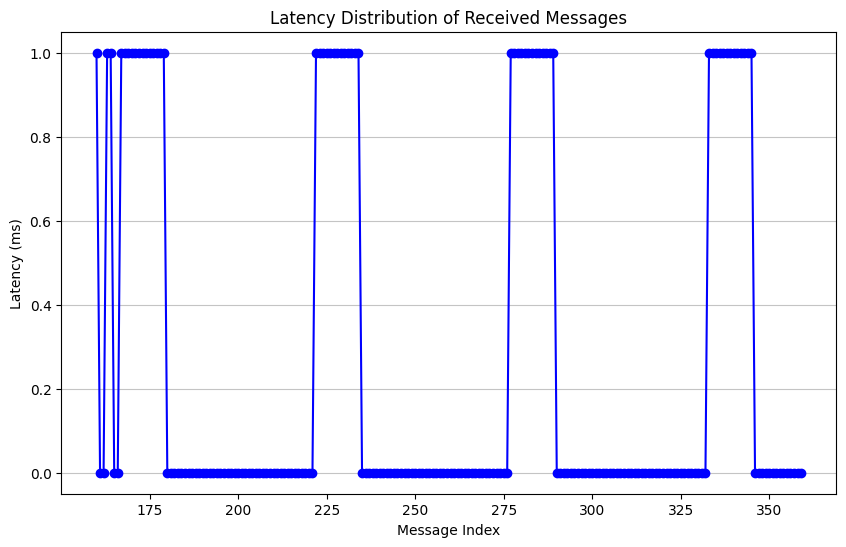

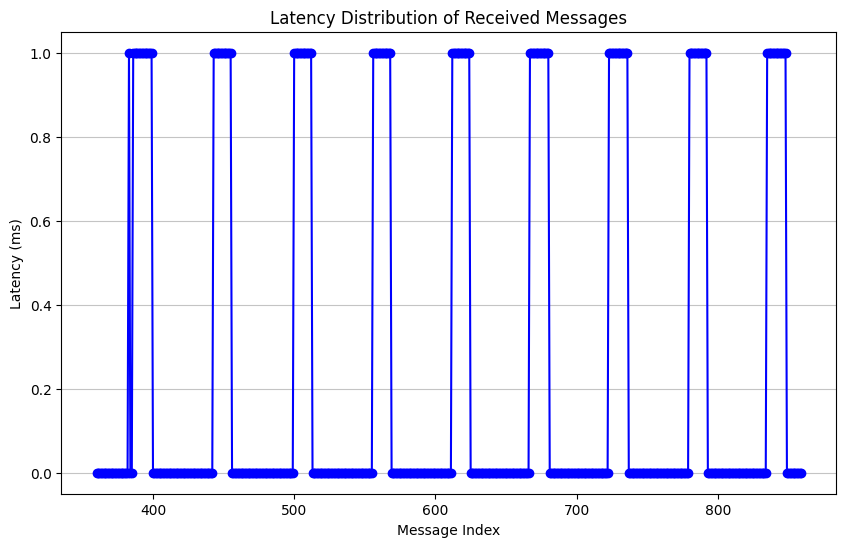

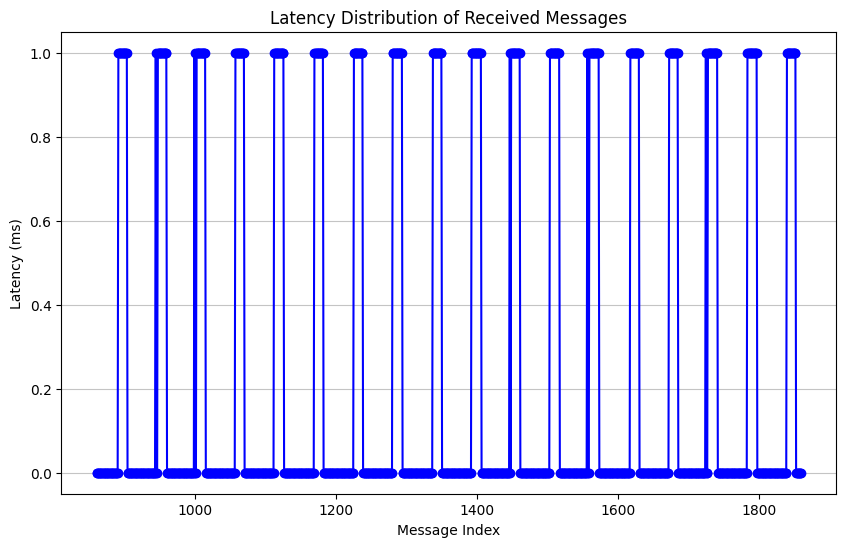

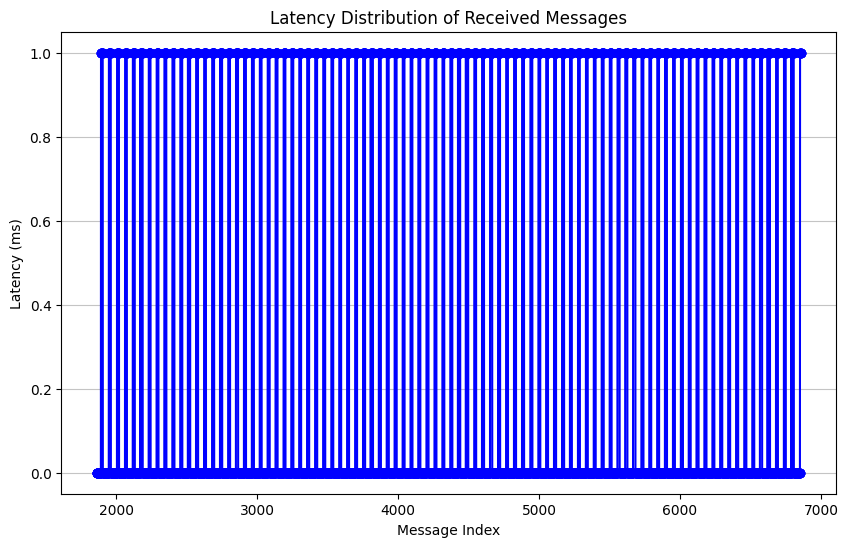

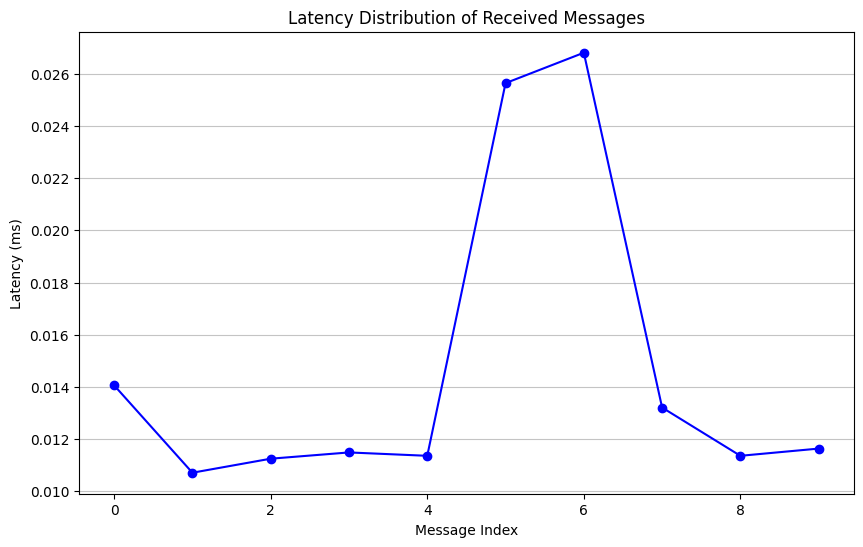

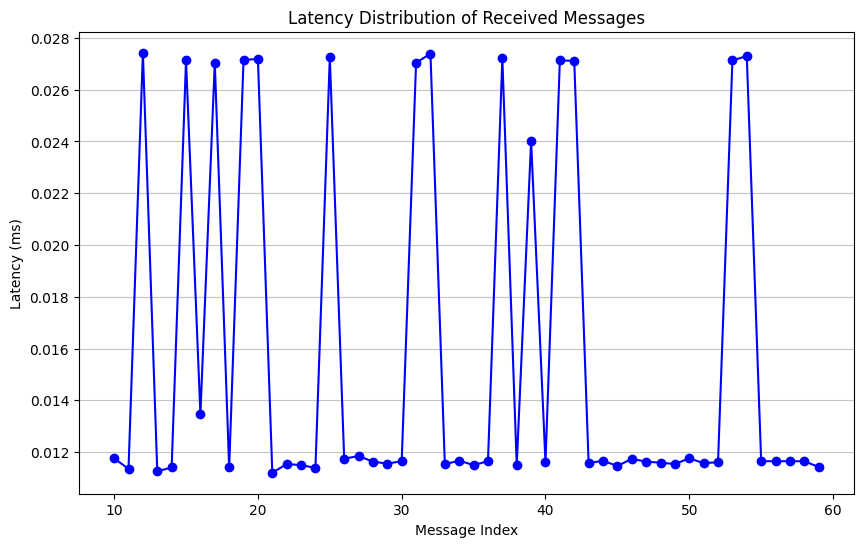

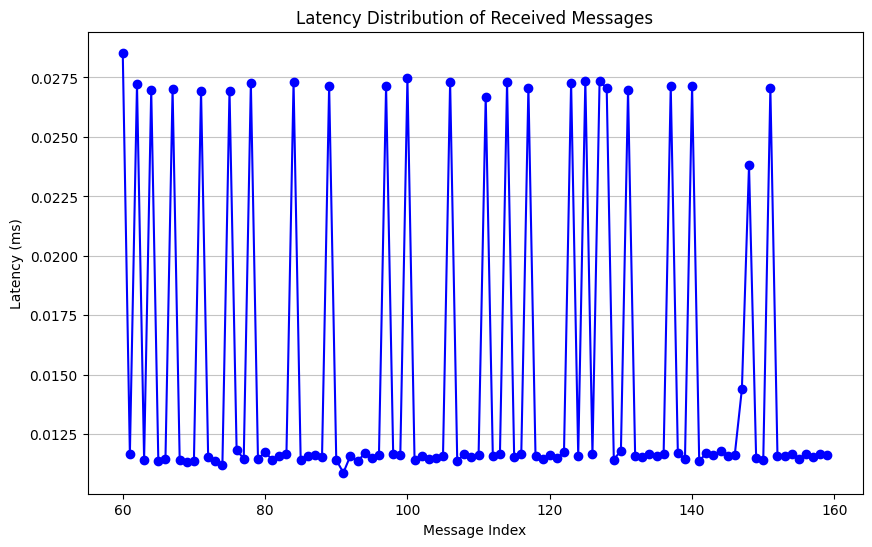

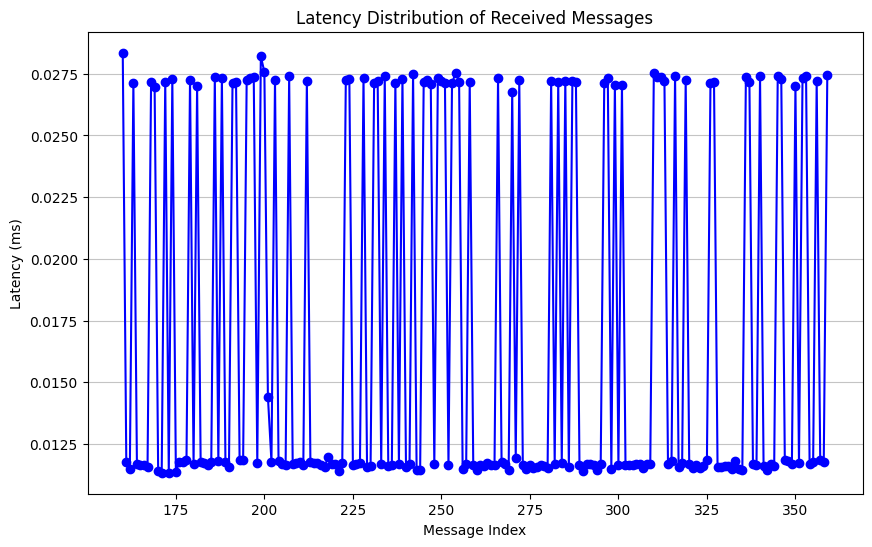

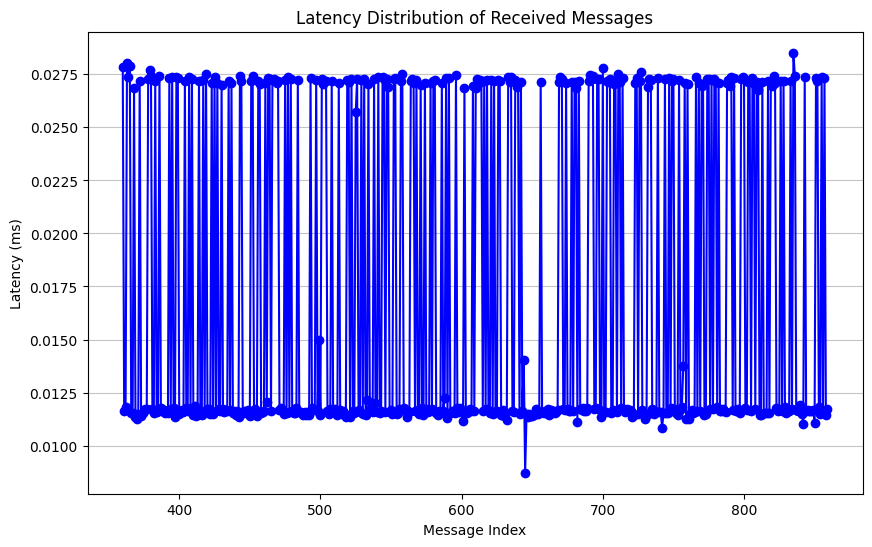

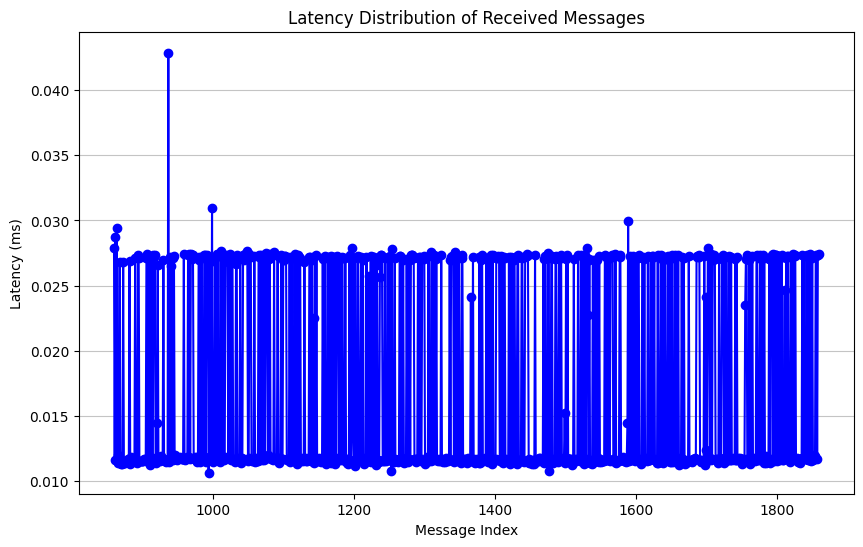

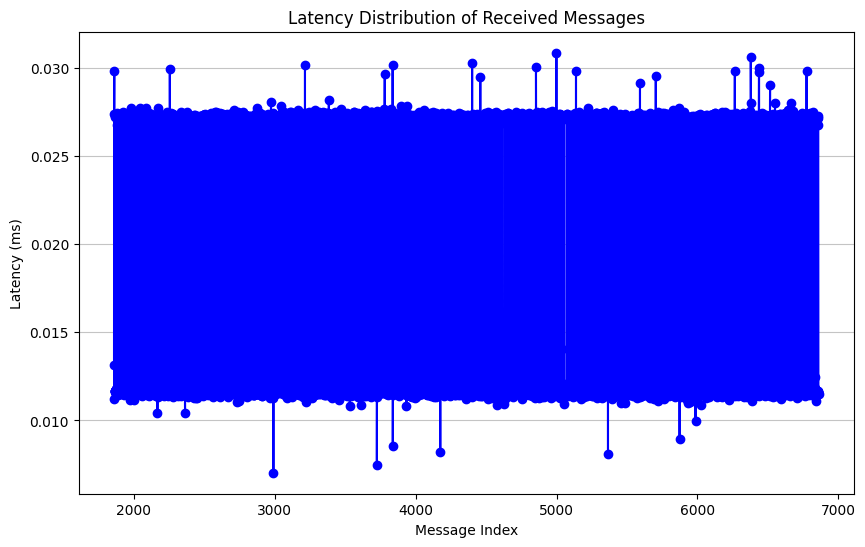

In [2]:
df = pd.read_csv('mensajes_recibidos2.csv')


df['latency'] = df['Receiving_Timestamp'] - df['Sending_Timestamp']

df.reset_index(inplace=True)



pruebas = [10, 50, 100, 200, 500, 1000, 5000]
lista = []
contador = 0
for prueba in pruebas:
    for i in range(0, prueba):
        lista.append(prueba)
        contador += 1



df['grupo'] = lista   

for prueba in pruebas:
    df2 = df[df['grupo'] == prueba]
    plt.figure(figsize=(10, 6))
    plt.plot(df2['index'], df2['latency'], marker='o', linestyle='-', color='blue')
    # plt.hist(df[df2]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_{prueba}.png')



print("Total messages processed:", contador)
print("Total messages dropped:", sum(pruebas) - contador)




fdf = pd.read_csv('resultados_experimento.csv')
ldf = pd.read_csv('resultados_experimento2.csv')


df['arrived_timestamp'] = fdf['timestamp_ns']
df['leaving_timestamp'] = ldf['timestamp_ns']

df['latency_s_s'] = (df['leaving_timestamp'] - df['arrived_timestamp'])/1000000



print(df)


for prueba in pruebas:
    df2 = df[df['grupo'] == prueba]
    plt.figure(figsize=(10, 6))
    plt.plot(df2['index'], df2['latency_s_s'], marker='o', linestyle='-', color='blue')
    # plt.hist(df[df2]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_s_s_{prueba}.png')
